Imports

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [7]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\TE_Intergenic_With_Distances_Cerebellum.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Expression_TE_DESeq_Cerebellum.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Clinical_Data_Gogliotti18.csv"

Histogram

     0         1         2                3     4  5          6           7   \
0  chr1   6466515   6466812  TE_AluSz_dup176  2137  +        Alu        SINE   
1  chr1  11305079  11306612    TE_SVA_C_dup2  9695  -        SVA  Retroposon   
2  chr1  13842901  13843186   TE_THE1D_dup35  1754  +  ERVL-MaLR         LTR   
3  chr1  16241468  16241573  TE_MLT1B_dup166   523  -  ERVL-MaLR         LTR   
4  chr1  16535843  16536004     TE_L2_dup253   367  +         L2        LINE   

     8         9         10               11 12 13     14  
0  chr1   6424775   6461367             ESPN  .  +   5149  
1  chr1  11311733  11319093  ENSG00000284646  .  -   5122  
2  chr1  13700187  13825079            PRDM2  .  +  17823  
3  chr1  16241212  16241398           MT1XP1  .  -     71  
4  chr1  16520693  16521796  ENSG00000224174  .  +  14048  
      Start      End  Count
0      1.00   499.45     95
1    499.45   997.90     30
2    997.90  1496.35     43
3   1496.35  1994.80     44
4   1994.80  2493.2

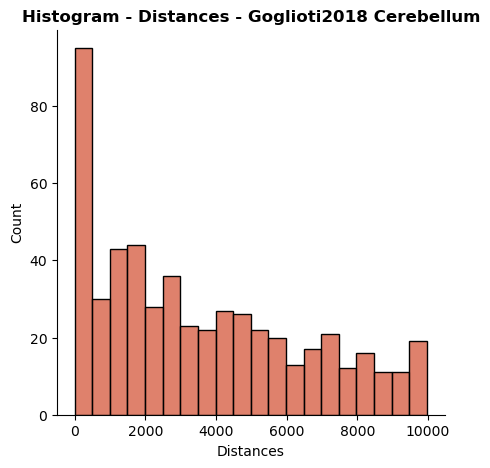

In [8]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
print(TEs_df.head())

TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Goglioti2018 Cerebellum', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA Intergenic - Data

In [9]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA)

# Merge to get intergenic
print(TEs_df.head())
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize clinical data
clinical_df = clinical_df[['Sample_Name', 'Sample_ID', 'Condition']]

# Separate names and counts
TEs_names = expr_df.iloc[:, 0]
counts = expr_df.iloc[:, 1:]

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm + 1)

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample_Name', how = 'inner')

pca_df.head()

  TE_Chr  TE_Start    TE_End          TE_Name  TE_Score TE_Strand TE_Class-id  \
0   chr1   6466515   6466812  TE_AluSz_dup176      2137         +         Alu   
1   chr1  11305079  11306612    TE_SVA_C_dup2      9695         -         SVA   
2   chr1  13842901  13843186   TE_THE1D_dup35      1754         +   ERVL-MaLR   
3   chr1  16241468  16241573  TE_MLT1B_dup166       523         -   ERVL-MaLR   
4   chr1  16535843  16536004     TE_L2_dup253       367         +          L2   

  TE_Family_id Gene_Chr  Gene_Start  Gene_End        Gene_Name Gene_Score  \
0         SINE     chr1     6424775   6461367             ESPN          .   
1   Retroposon     chr1    11311733  11319093  ENSG00000284646          .   
2          LTR     chr1    13700187  13825079            PRDM2          .   
3          LTR     chr1    16241212  16241398           MT1XP1          .   
4         LINE     chr1    16520693  16521796  ENSG00000224174          .   

  Gene_Strand  Distances  
0           +       514

,Sample_Name,PC1,PC2,Sample_ID,Condition
0,Cer_Ctrl_1,10.902708,7.715029,3325-CMN-18,Ctrl
1,Cer_Ctrl_2,2.059447,10.298339,3325-CMN-19,Ctrl
2,Cer_Ctrl_3,-3.976647,11.956648,3325-CMN-20,Ctrl
3,Cer_Ctrl_4,6.027775,11.114249,3325-CMN-21,Ctrl
4,Cer_Ctrl_5,-5.661703,3.060652,3325-CMN-22,Ctrl


PCA - Graph

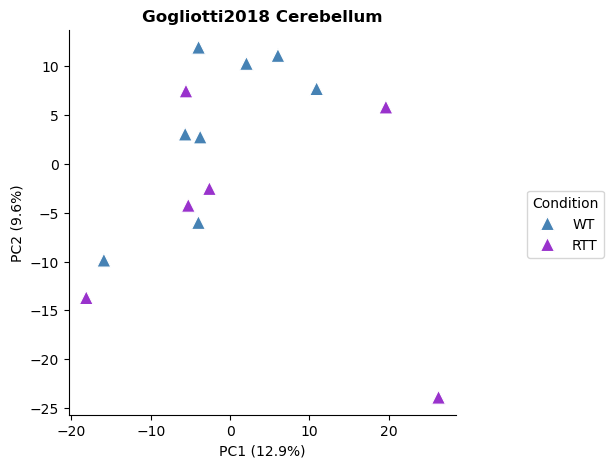

In [12]:
fig, ax = plt.subplots(figsize = (5 ,5))

palette_pca = {
    'RTT' : 'darkorchid',
    'WT' : 'steelblue'
}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(pca_df, x = 'PC1', y = 'PC2', hue = 'Condition', palette = palette_pca, s = 100, marker = '^')

# Labels
ax.set_title('Gogliotti2018 Cerebellum', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()